In [40]:
import matplotlib.pyplot as plt


def predict(x, w, b):
    return w * x + b

# Compute Gradient
def compute_gradient(y_hat, y, x):
    dw=2*x*(y_hat-y)
    db=2*(y_hat-y)
    return (dw, db)

# Update Parameter
def update_paramters(w, b, lr, dw, db):
    w_new=w-lr*dw
    b_new=b-lr*db
    return (w_new, b_new)

# Loss Function
def compute_loss(y_hat, y):
    return (y_hat-y)**2

# Plotting the chart
def plot_chart( w, b, x_values=[3.5, 4.6, 5.5, 6.7], y_values=[4.6, 5.9, 6.7, 9.1]) -> None:
    line_x = [3.0, 7.0]
    line_y = [predict(x, w, b) for x in line_x]

    plt.scatter(x_values, y_values)
    plt.plot(line_x, line_y, color="red")

    equation = f"y = {w:.2f}x + {b:.2f}"
    plt.text(line_x[0]+0.7, line_y[0] + 0.5, equation, color="red")

    plt.xlim(2.8, 7.2)
    plt.ylim(-3, 9.6)
    plt.show()

def simple_linear_regression():
    x=6.7
    y=9.1
    b=0.04
    w=-0.34
    plot_chart(w, b)
    y_hat=predict(x, w, b)
    print("Initial Loss: ", compute_loss(y_hat, y))
    for i in range(2):
        y_hat=predict(x, w, b)
        dw, db=compute_gradient(y_hat, y, x)
        (w_new, b_new)=update_paramters(w, b, 0.01, dw, db)
        y_hat=predict(x, w_new, b_new)
        loss=compute_loss(y_hat, y)
        print("Updated Loss: ", loss)
        w=w_new
        b=b_new
        plot_chart(w, b)

def one_sample_training():
    # Initialization
    b = 0.4
    w=-0.34
    lr=0.01
    # How long
    epoch_max=10
    data_size=4
    # Training Data
    X_values=[6.7, 4.7, 3.5, 5.5]
    y_values=[9.1, 5.9, 4.6, 6.7]
    losses=[]
    for epoch in range(epoch_max):
        for i in range(data_size):
            x=X_values[i]
            y=y_values[i]

            y_hat=predict(x, w, b)
            
            dw, db=compute_gradient(y_hat, y, x)
            
            w, b = update_paramters(w, b, lr, dw, db)

            loss=compute_loss(y_hat, y)
            losses.append(loss)
        print(f"Epoch: {epoch+1}, w: {w:.2f}, b: {b:.2f}")
    plot_chart(w, b, X_values, y_values)
    plt.plot(losses)
    plt.show()

In [ ]:
# Initialization
b = 0.04
w=-0.34
lr=0.02
# How long
epoch_max=10
data_size=4
# Training Data
X_values=[6.7, 4.6, 3.5, 5.5]
y_values=[9.1, 5.9, 4.6, 6.7]
epoch_max = 10
losses = [] # for debug

for epoch in range(epoch_max):
    
    # for an epoch    
    for i in range(4):
        
        # get a sample
        x = X_values[i]
        y = y_values[i]      
        
        # predict y_hat
        y_hat = predict(x, w, b)

        # compute loss
        loss = (y_hat-y)*(y_hat-y)
        
        # for debug
        losses.append(loss)
        print(loss)

        # compute gradient
        (dw, db) = compute_gradient(y_hat, y, x)

        # update weights
        (w, b) = update_paramters(w, b, lr, dw, db)

128.550244
49.09813868964093
0.2978666638171294
0.6761546819648765
1.4961961729515123
1.2421558961808372
0.0005958270445172143
0.20619980459758444
1.227290769192806
1.0862982111039632
0.00020202921498897256
0.20772372381330653
1.2206101856626983
1.072086600947402
9.585957527677484e-05
0.21303364196383398
1.2167572802447408
1.0595691504116764
2.984811025072228e-05
0.2184154503006066
1.2129687722154336
1.047230121315139
1.36272760749999e-06
0.22382593527869668
1.2092133726087544
1.0350504441855346
9.598186231460192e-06
0.22926347757442328
1.2054904186072315
1.02302778720548
5.377644012572535e-05
0.23472695224819373
1.2017995942617465
1.0111600347032241
0.00013313238164334098
0.24021526082354577
1.1981405908472518
0.9994451022376798
0.0002469135567324983
0.24572732563292451


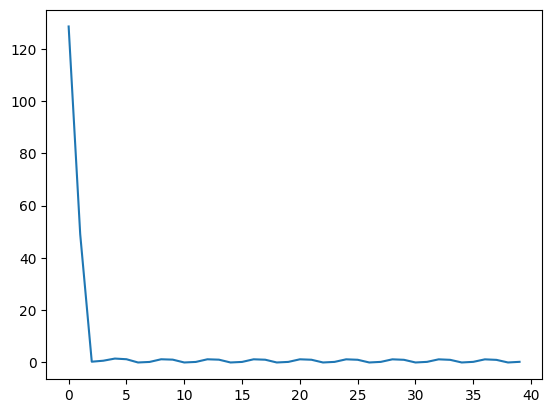

In [8]:
plt.plot(losses) 

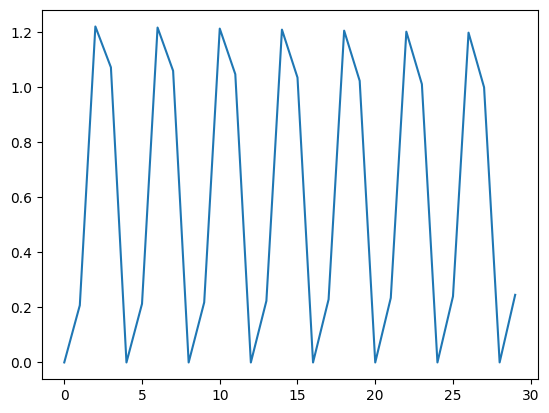

In [13]:
plt.plot(losses[10:])

In [17]:
# Predict
def predict(x, w, b):
    return w * x + b

# Compute Gradient
def compute_gradient(y_hat, y, x):
    dw=2*x*(y_hat-y)
    db=2*(y_hat-y)
    return (dw, db)

# Update Parameter
def update_paramters(w, b, lr, dw, db):
    w_new=w-lr*dw
    b_new=b-lr*db
    return (w_new, b_new)

# Loss Function
def compute_loss(y_hat, y):
    return (y_hat-y)**2

In [ ]:
# Initialization
b = 0.04
w=-0.34
lr=0.02
# How long
epoch_max=10
data_size=4
# Training Data
X_values=[6.7, 4.6, 3.5, 5.5]
y_values=[9.1, 5.9, 4.6, 6.7]
N=4
m=2
losses=[]
# Implementation
for _ in range(epoch_max):
    for i in range(0, N, m):
        dw, db = [], []
        loss_total=0
        for j in range(m):
            X=X_values[i+j]
            y=y_values[i+j]

            y_hat=predict(X, w, b)
            loss_total+=compute_loss(y_hat, y)
            
            grad_w, grad_b = compute_gradient(y_hat, y, X)
            dw.append(grad_w)
            db.append(grad_b)

        losses.append(loss_total/m)
        combined_dw=sum(dw)/m
        combined_db=sum(db)/m
        w, b = update_paramters(w, b, lr, combined_dw, combined_db)

print(len(losses))

30


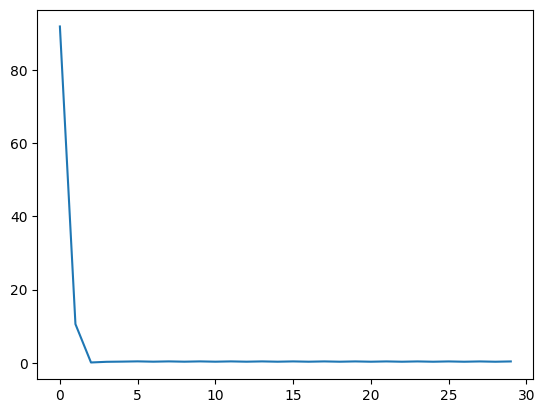

In [73]:
plt.plot(losses)

In [51]:
def plot_chart( w, b, x_values=[3.5, 4.6, 5.5, 6.7], y_values=[4.6, 5.9, 6.7, 9.1]) -> None:
    line_x = [3.0, 7.0]
    line_y = [predict(x, w, b) for x in line_x]

    plt.scatter(x_values, y_values)
    plt.plot(line_x, line_y, color="red")

    equation = f"y = {w:.2f}x + {b:.2f}"
    plt.text(line_x[0]+0.7, line_y[0] + 0.5, equation, color="red")

    plt.xlim(2.8, 7.2)
    plt.ylim(-3, 9.6)
    plt.show()

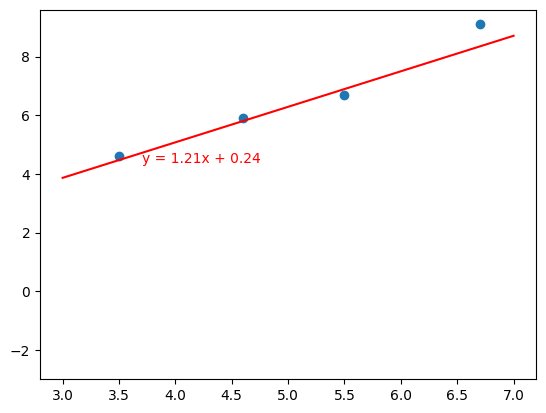

In [57]:
plot_chart(w,b)